In [23]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

import functions.eddy_feedback as ef
import functions.data_wrangling as dw

# Data Import

In [24]:
path = '/home/links/ct715/data_storage/reanalysis/jra55_daily/processed_efp'

# Primitive data import
path_6h_pr = os.path.join(path, '6h_ubar_epf-pr-QG_1MS_1958-2016.nc')
ds_6h_pr = xr.open_dataset(path_6h_pr)
ds_6h_pr = ds_6h_pr.sel(level=slice(950, 100))
ds_6h_pr = ds_6h_pr.sel(lat=slice(0, 87.5))

# QG data import
path_6h = os.path.join(path, 'k123_6h_ubar_epf-pr-QG_1MS_1958-2016.nc')
ds_6h = xr.open_dataset(path_6h)
ds_6h = ds_6h.sel(level=slice(950, 100))
ds_6h = ds_6h.sel(lat=slice(0, 87.5))

# Define ubar
ubar = ds_6h['ubar']
ubar_djf = dw.seasonal_mean(ubar, season='djf')
ubar_djf = ubar_djf.mean(dim='time')

# QG k123 Comparison

In [25]:
# div1_QG
div1 = ds_6h['div1_QG']
div1_djf = dw.seasonal_mean(div1, season='djf')
div1_djf = div1_djf.mean(dim='time')

k123 = ds_6h['div1_QG_123']
k123_djf = dw.seasonal_mean(k123, season='djf')
k123_djf = k123_djf.mean(dim='time')

gt3 = ds_6h['div1_QG_gt3']
gt3_djf = dw.seasonal_mean(gt3, season='djf')
gt3_djf = gt3_djf.mean(dim='time')

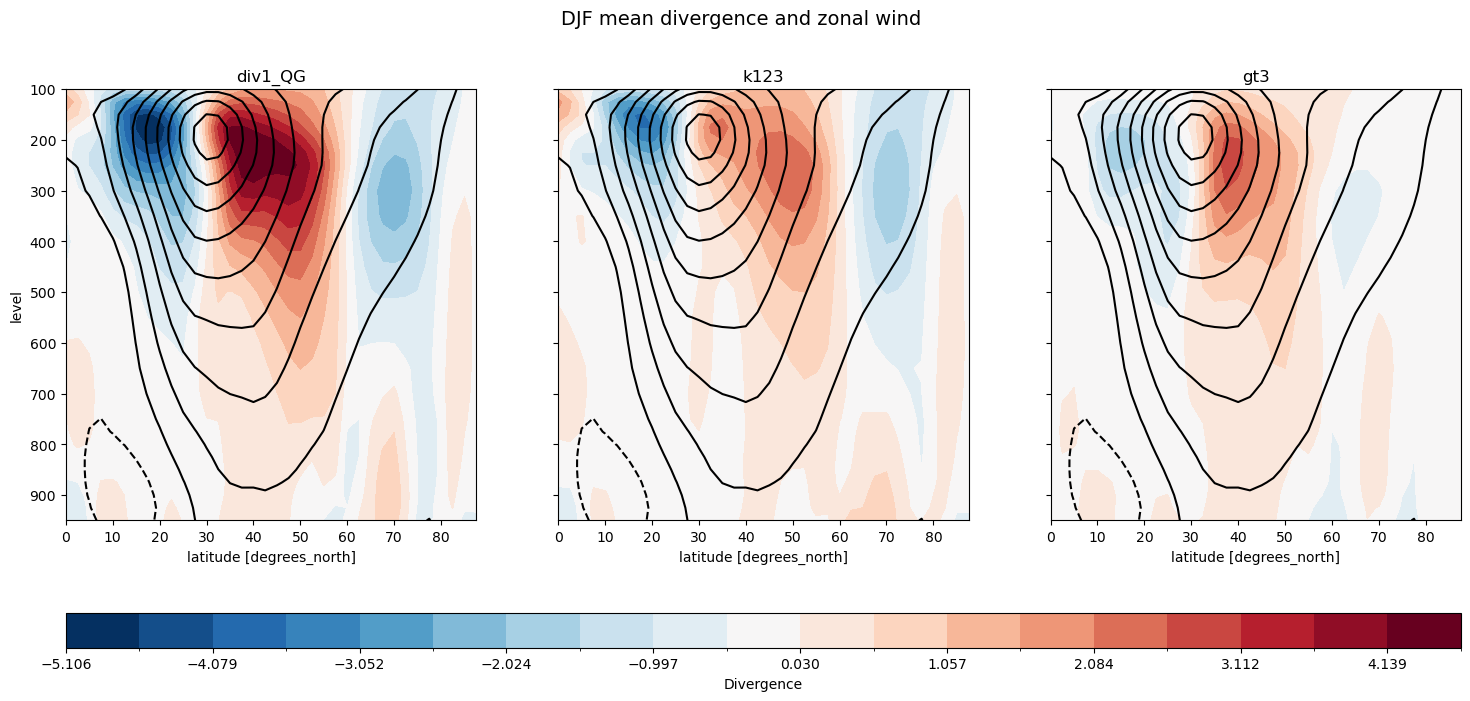

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(18, 8), sharey=True)

# Calculate global vmin/vmax for consistent colorbar
data_list = [div1_djf, k123_djf, gt3_djf]
vmin = min(data.min().values for data in data_list)
vmax = max(data.max().values for data in data_list)

# ax1 QG divergence
im1 = div1_djf.plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', 
                              yincrease=False, ax=ax1, vmin=vmin, vmax=vmax, 
                              add_colorbar=False)
ubar_djf.plot.contour(x='lat', y='level', levels=20, colors='k', yincrease=False, ax=ax1)
ax1.set_title('div1_QG')

# ax2 QG divergence
im2 = k123_djf.plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', 
                                 yincrease=False, ax=ax2, vmin=vmin, vmax=vmax, 
                                 add_colorbar=False)
ubar_djf.plot.contour(x='lat', y='level', levels=20, colors='k', yincrease=False, ax=ax2)
ax2.set_title('k123')
ax2.set_ylabel('')  # Remove y-label from middle plot since y-axis is shared

# ax3 difference
im3 = gt3_djf.plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', 
                                              yincrease=False, ax=ax3, vmin=vmin, vmax=vmax, 
                                              add_colorbar=False)
ubar_djf.plot.contour(x='lat', y='level', levels=20, colors='k', yincrease=False, ax=ax3)
ax3.set_title('gt3')
ax3.set_ylabel('')  # Remove y-label from rightmost plot

# Add single colorbar for all plots
cbar = fig.colorbar(im1, ax=[ax1, ax2, ax3], orientation='horizontal', 
                    pad=0.15, aspect=40)
cbar.set_label('Divergence')

fig.suptitle('DJF mean divergence and zonal wind', fontsize=14)
plt.show()

# QG vs Primitive

In [27]:
# div1_pr
div1_pr = ds_6h_pr['div1_pr']
div1_pr_djf = dw.seasonal_mean(div1_pr, season='djf')
div1_pr_djf = div1_pr_djf.mean(dim='time')

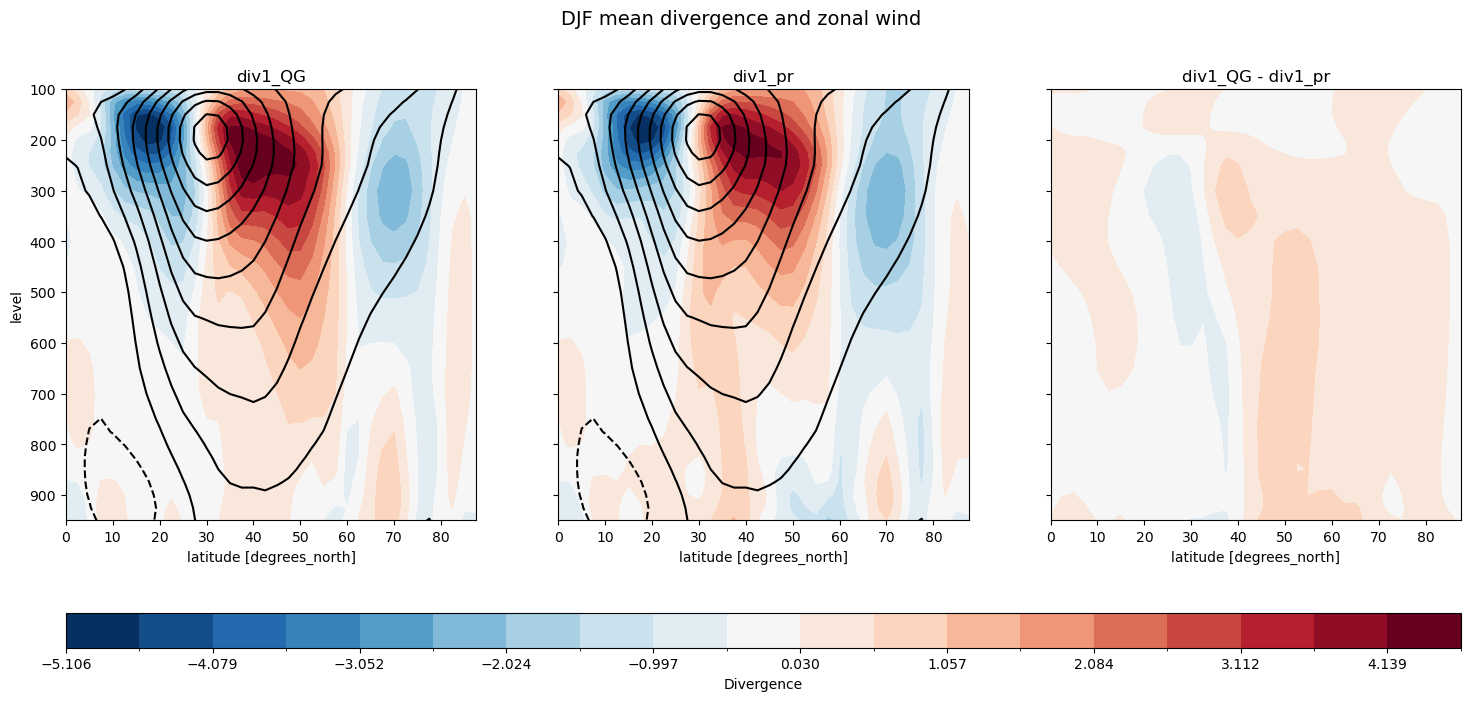

In [28]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(18, 8), sharey=True)

# Calculate global vmin/vmax for consistent colorbar
data_list = [div1_djf, div1_pr_djf, (div1_djf - div1_pr_djf)]
vmin = min(data.min().values for data in data_list)
vmax = max(data.max().values for data in data_list)

# ax1 QG divergence
im1 = div1_djf.plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', 
                              yincrease=False, ax=ax1, vmin=vmin, vmax=vmax, 
                              add_colorbar=False)
ubar_djf.plot.contour(x='lat', y='level', levels=20, colors='k', yincrease=False, ax=ax1)
ax1.set_title('div1_QG')

# ax2 QG divergence
im2 = div1_pr_djf.plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', 
                                 yincrease=False, ax=ax2, vmin=vmin, vmax=vmax, 
                                 add_colorbar=False)
ubar_djf.plot.contour(x='lat', y='level', levels=20, colors='k', yincrease=False, ax=ax2)
ax2.set_title('div1_pr')
ax2.set_ylabel('')  # Remove y-label from middle plot since y-axis is shared

# ax3 difference
im3 = (div1_djf - div1_pr_djf).plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', 
                                              yincrease=False, ax=ax3, vmin=vmin, vmax=vmax, 
                                              add_colorbar=False)
ax3.set_title('div1_QG - div1_pr')
ax3.set_ylabel('')  # Remove y-label from rightmost plot

# Add single colorbar for all plots
cbar = fig.colorbar(im1, ax=[ax1, ax2, ax3], orientation='horizontal', 
                    pad=0.15, aspect=40)
cbar.set_label('Divergence')

fig.suptitle('DJF mean divergence and zonal wind', fontsize=14)
plt.show()

# 6-hourly

## Northern Hemisphere

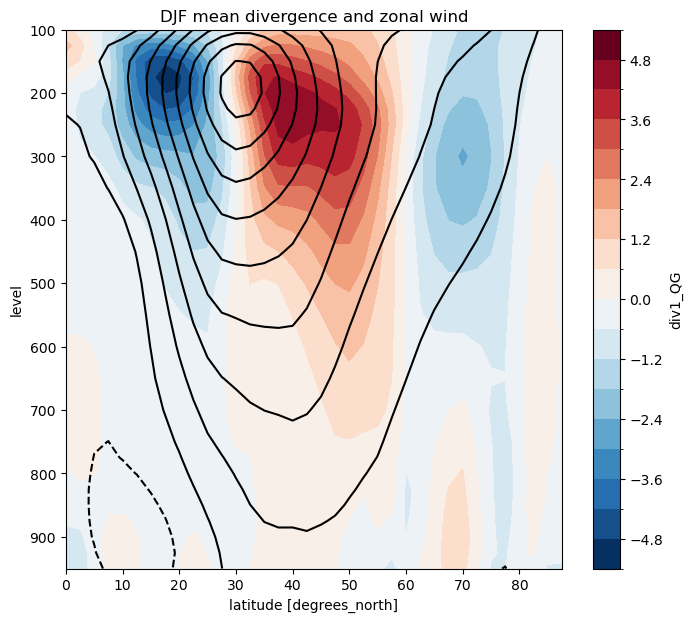

In [35]:
plt.figure(figsize=(8,7))

div1_djf.plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', yincrease=False)
ubar_djf.plot.contour(x='lat', y='level', levels=20, colors='k', yincrease=False)
plt.title('DJF mean divergence and zonal wind')

plt.show()

## Combined winters

In [29]:
ubar_jas = dw.seasonal_mean(ubar, season='jas')
ubar_jas = ubar_jas.mean(dim='time')

div1_jas = dw.seasonal_mean(div1, season='jas')
div1_jas = div1_jas.mean(dim='time')

/tmp/ipykernel_108212/2395723359.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


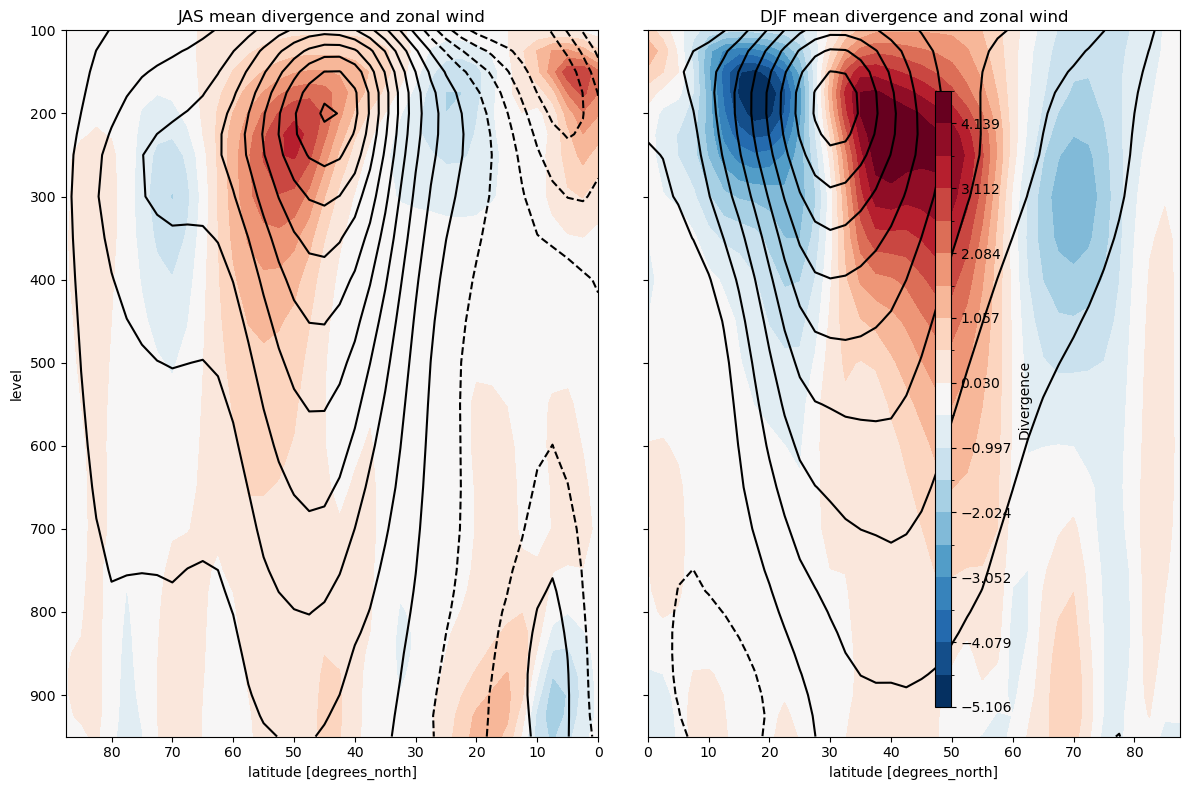

In [33]:
import numpy as np

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 8), sharey=True)

# Calculate global vmin/vmax for consistent colorbar
vmin = min(div1_jas.min().values, div1_djf.min().values)
vmax = max(div1_jas.max().values, div1_djf.max().values)

# ax1 JAS
im1 = div1_jas.plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', 
                              yincrease=False, ax=ax1, vmin=vmin, vmax=vmax, 
                              add_colorbar=False)
ubar_jas.plot.contour(x='lat', y='level', levels=20, colors='k', yincrease=False, ax=ax1)
ax1.invert_xaxis()  # Flip x-axis so lat=0 is on RHS
ax1.set_title('JAS mean divergence and zonal wind')

# ax2 DJF
im2 = div1_djf.plot.contourf(x='lat', y='level', levels=20, cmap='RdBu_r', 
                              yincrease=False, ax=ax2, vmin=vmin, vmax=vmax, 
                              add_colorbar=False)
ubar_djf.plot.contour(x='lat', y='level', levels=20, colors='k', yincrease=False, ax=ax2)
ax2.set_title('DJF mean divergence and zonal wind')
ax2.set_ylabel('')  # Remove y-label since y-axis is shared

# Add single colorbar
cbar = fig.colorbar(im1, ax=[ax1, ax2], orientation='vertical', pad=0.15, aspect=40)
cbar.set_label('Divergence')

plt.tight_layout()
plt.show()